# 1️⃣ IMPORTS

In [43]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Bidirectional, Dense, Dropout, SpatialDropout1D

from tensorflow.keras.callbacks import EarlyStopping

In [44]:
# 2. LOAD DATASET
df = pd.read_csv(
    "/content/final_fashion_dataset_LAST.csv",
    encoding='latin1'
)

# 2️⃣ CLEAN DATA

In [45]:
df = df.drop_duplicates()
df = df.dropna()
df = df.reset_index(drop=True)
df["description"] = df["description"].str.lower().str.strip()
print(df.shape)
print(df["label"].value_counts())


(1203, 3)
label
bags       210
shoes      206
outfit     192
pants      168
shirts     168
skirt      153
watches    106
Name: count, dtype: int64


In [46]:
import re

def clean_text(text):
    text = re.sub(r'category:.*', '', text.lower())
    return text.strip()

df["description"] = df["description"].apply(clean_text)

# 3️⃣ LABEL ENCODING

In [47]:
encoder = LabelEncoder()

y = encoder.fit_transform(df["label"])
num_classes = len(encoder.classes_)

print(encoder.classes_)

['bags' 'outfit' 'pants' 'shirts' 'shoes' 'skirt' 'watches']


In [48]:
df.to_csv("/content/clean_fashion_dataset.csv", index=False, encoding="utf-8")

# 4️⃣ TRAIN / VAL / TEST SPLIT

In [49]:
X_train, X_temp, y_train, y_temp = train_test_split(
    df["description"],
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

# 5️⃣ TOKENIZER

In [50]:
max_words = 20000
max_len = 25

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# 6️⃣ TEXT → SEQUENCES

In [51]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# 7️⃣ PADDING

In [52]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# 8️⃣ CLASS WEIGHTS

In [53]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights))

print(class_weights)

{np.int64(0): np.float64(0.8180272108843537), np.int64(1): np.float64(0.8923933209647495), np.int64(2): np.float64(1.0255863539445629), np.int64(3): np.float64(1.0255863539445629), np.int64(4): np.float64(0.8329004329004329), np.int64(5): np.float64(1.126463700234192), np.int64(6): np.float64(1.6168067226890757)}


# 9️⃣ MODEL (SMART GRU)

In [54]:
model = Sequential()

# Embedding (learns word meanings)
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))

# Regularization
model.add(SpatialDropout1D(0.4))

# GRU (understands sequence)
model.add(Bidirectional(GRU(64, dropout=0.4, recurrent_dropout=0.4)))

# Dense layer
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

# Output
model.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


# 🔟 COMPILE

In [55]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 1️⃣1️⃣ EARLY STOPPING (PREVENT OVERFITTING)

In [56]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 1️⃣2️⃣ TRAIN MODEL

In [57]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=20,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 17s 177ms/step - accuracy: 0.2058 - loss: 1.9264 - val_accuracy: 0.5750 - val_loss: 1.8453
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 165ms/step - accuracy: 0.4137 - loss: 1.4980 - val_accuracy: 0.7000 - val_loss: 0.9576
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.6362 - loss: 0.8898 - val_accuracy: 0.7917 - val_loss: 0.5526
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.7131 - loss: 0.6650 - val_accuracy: 0.8000 - val_loss: 0.4634
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.7911 - loss: 0.5455 - val_accuracy: 0.8250 - val_loss: 0.3695
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.8056 - loss: 0.4444 - val_accuracy: 0.8333 - val_loss: 0.3480
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.8274 - loss: 0.4040 - val_accuracy: 0.8500 - val_loss: 0.3101
Epoch 8/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.8254 - loss: 0.3895 - val_accur

# *1️⃣3️⃣ EVALUATION*

In [58]:
model.evaluate(X_test_pad, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8760 - loss: 0.2182


[0.21815550327301025, 0.8760330677032471]

In [59]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [60]:
y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.array(y_test)

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 373ms/step


In [61]:
# =========================================
# TRAIN & TEST ACCURACY + LOSS
# =========================================

# Train Evaluation
train_loss, train_acc = model.evaluate(X_train_pad, y_train, verbose=0)

# Test Evaluation
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)

print("\n========== MODEL PERFORMANCE ==========\n")

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Train Loss     : {train_loss:.4f}")

print("\n-----------------------------\n")

print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Loss      : {test_loss:.4f}")


========== MODEL PERFORMANCE ==========

Train Accuracy : 0.9044
Train Loss     : 0.2032

-----------------------------

Test Accuracy  : 0.8760
Test Loss      : 0.2182


In [62]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       0.88      0.79      0.83        19
           2       0.60      0.53      0.56        17
           3       0.71      0.88      0.79        17
           4       1.00      0.95      0.98        21
           5       0.94      1.00      0.97        16
           6       1.00      1.00      1.00        10

    accuracy                           0.88       121
   macro avg       0.88      0.88      0.88       121
weighted avg       0.88      0.88      0.87       121



# 1️⃣4️⃣Feature Extraction

In [63]:
from tensorflow.keras.models import Model

feature_model = Model(
    inputs=model.layers[0].input,
    outputs=model.layers[-2].output
)

In [64]:
feature_model.save("gru_feature_extractor.keras")

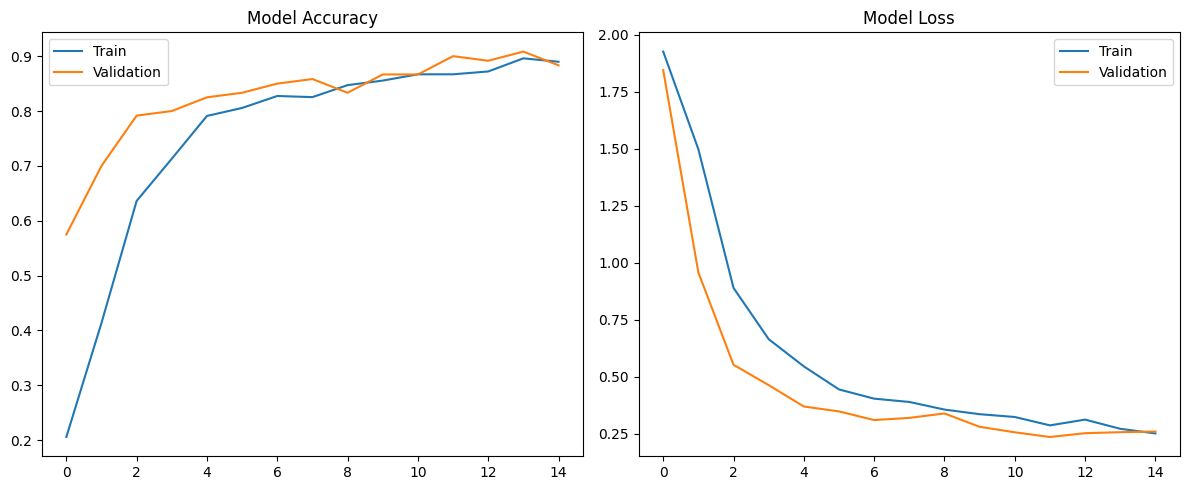

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# =========================
# Accuracy subplot
# =========================
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])

# =========================
# Loss subplot
# =========================
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train', 'Validation'])

plt.tight_layout()
plt.show()

# 1️⃣4️⃣ SMART PREDICTION

In [66]:
def predict_text(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len, padding='post')
    pred = model.predict(pad)

    label = encoder.inverse_transform([np.argmax(pred)])

    print("Text:", text)
    print("Predicted:", label[0])


#  هنا التشغيل الحقيقي
predict_text("blue denim pants straight cut")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Text: blue denim pants straight cut
Predicted: outfit


In [67]:
def predict_text(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len, padding='post')
    pred = model.predict(pad)

    label = encoder.inverse_transform([np.argmax(pred)])

    print("Text:", text)
    print("Predicted:", label[0])


# هنا التشغيل الحقيقي
predict_text("black leather handbag with gold chain")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Text: black leather handbag with gold chain
Predicted: bags


In [68]:
model.save("gru_fashion_model.keras")

In [69]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [70]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

# تحميلهم بعد كده (للـ similarity)

In [71]:
#Load model
from tensorflow.keras.models import load_model

model = load_model("gru_feature_extractor.keras")

In [72]:
#Load Tokenizer
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

In [73]:
#Load Encoder
with open("label_encoder.pkl", "rb") as f:
    encoder = pickle.load(f)